## Setup

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from utils.hist_utils import stacked_by_species

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS, SPECIES_ALL,
                                 species_label)

TRACKS_PATH = PROJECT_ROOT / "prepared" / "prepared-mc" / "test_tracks.pkl"
with open(TRACKS_PATH, "rb") as f:
    tracks = pickle.load(f)
species = np.array([species_label(t) for t in tracks])
Ntot = len(tracks)

PLOTS_DIR = PROJECT_ROOT / "plots" / "plot-observables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 1D observables by species

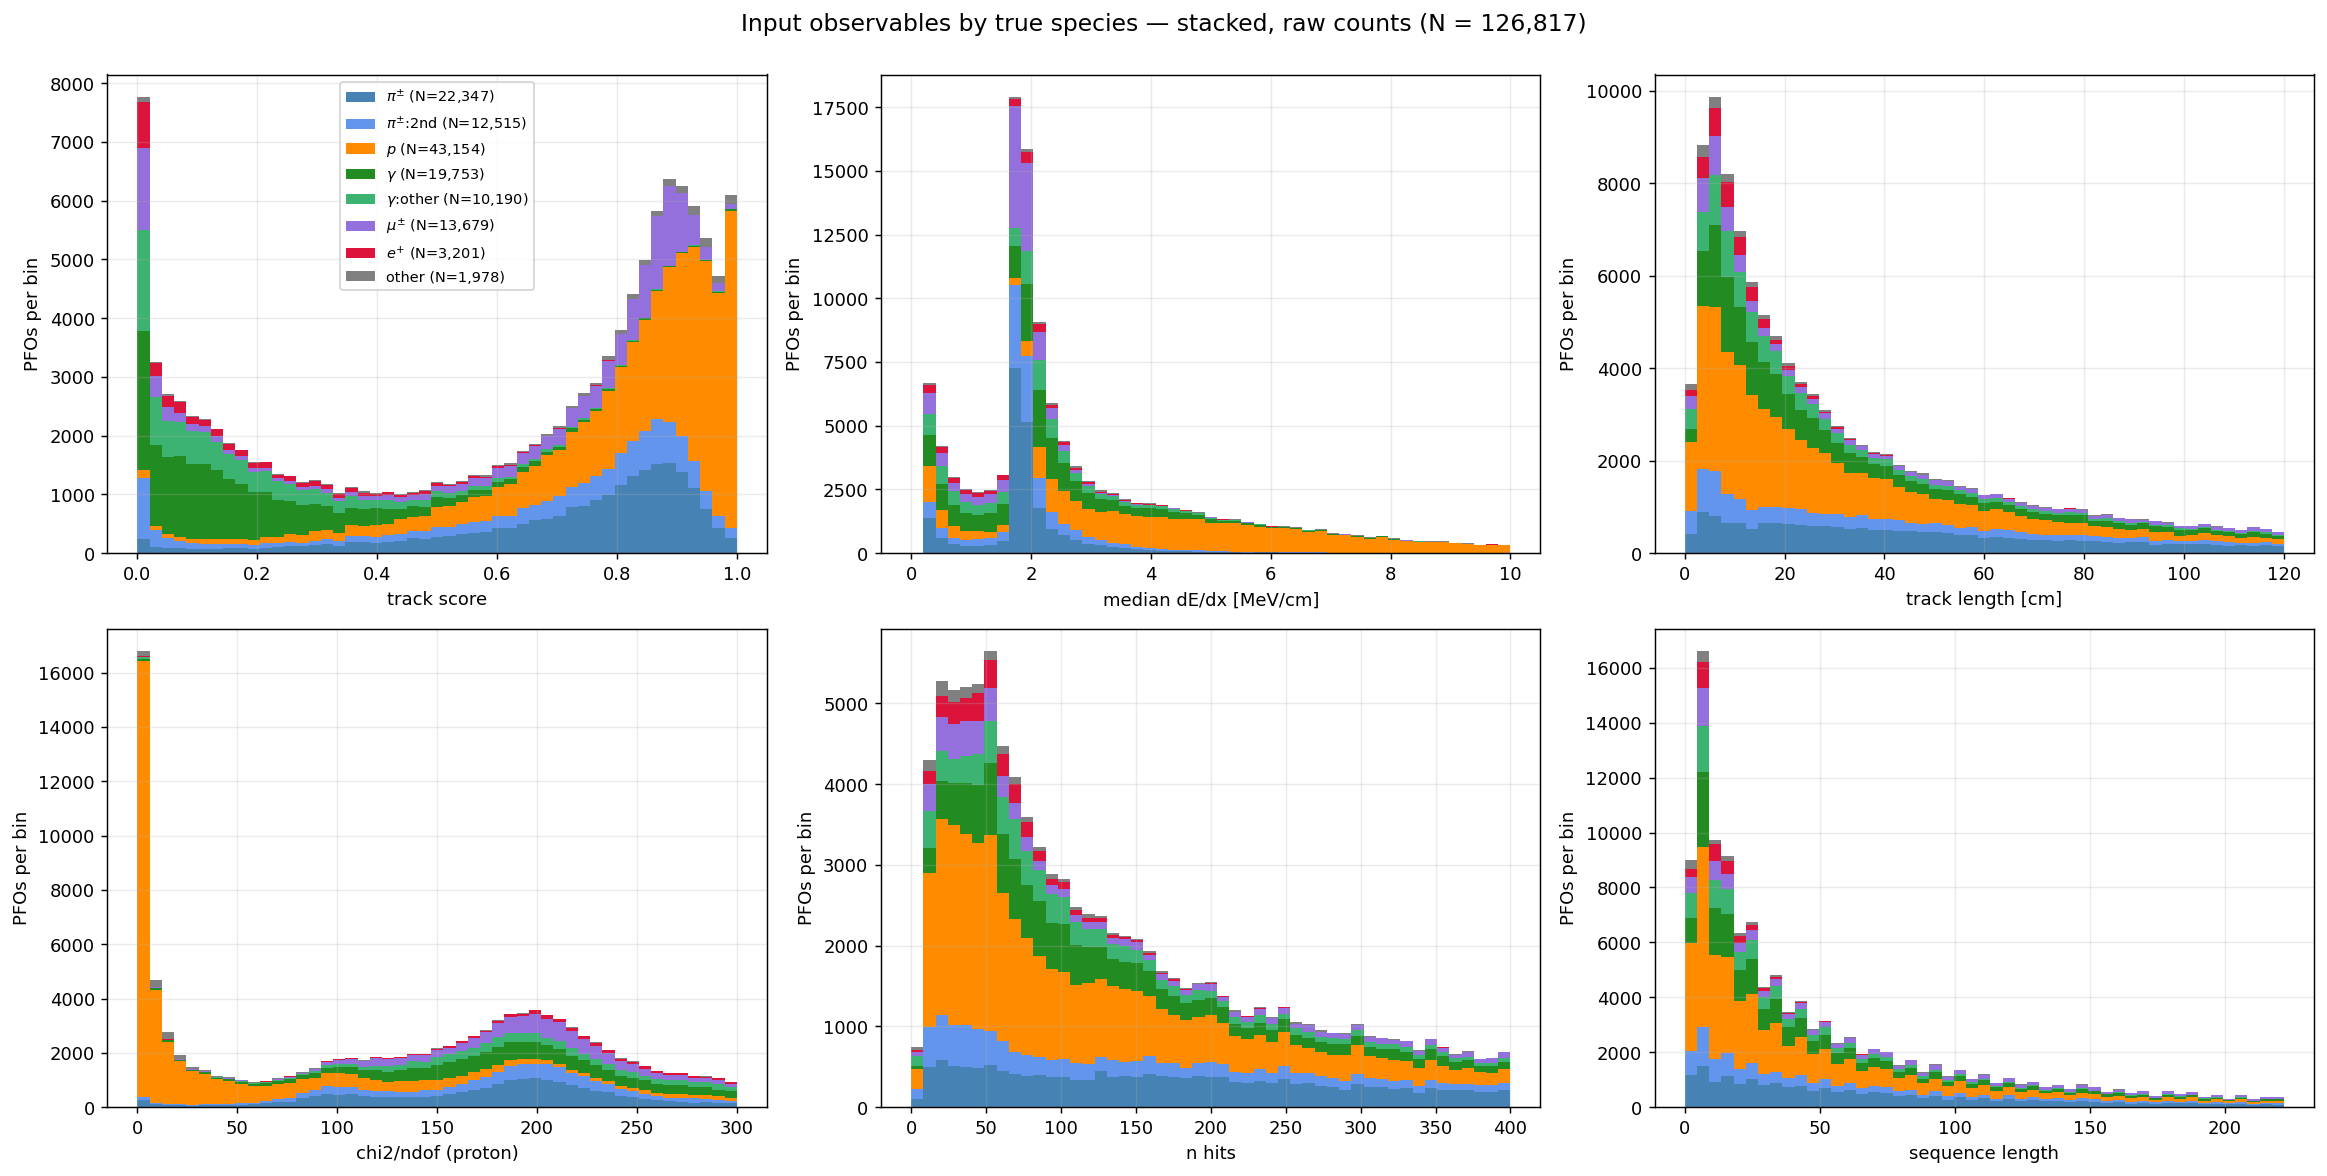

Saved /home/pemb7173/PDSP-pion-classification/plots/plot-observables/observables_1D_stacked.pdf


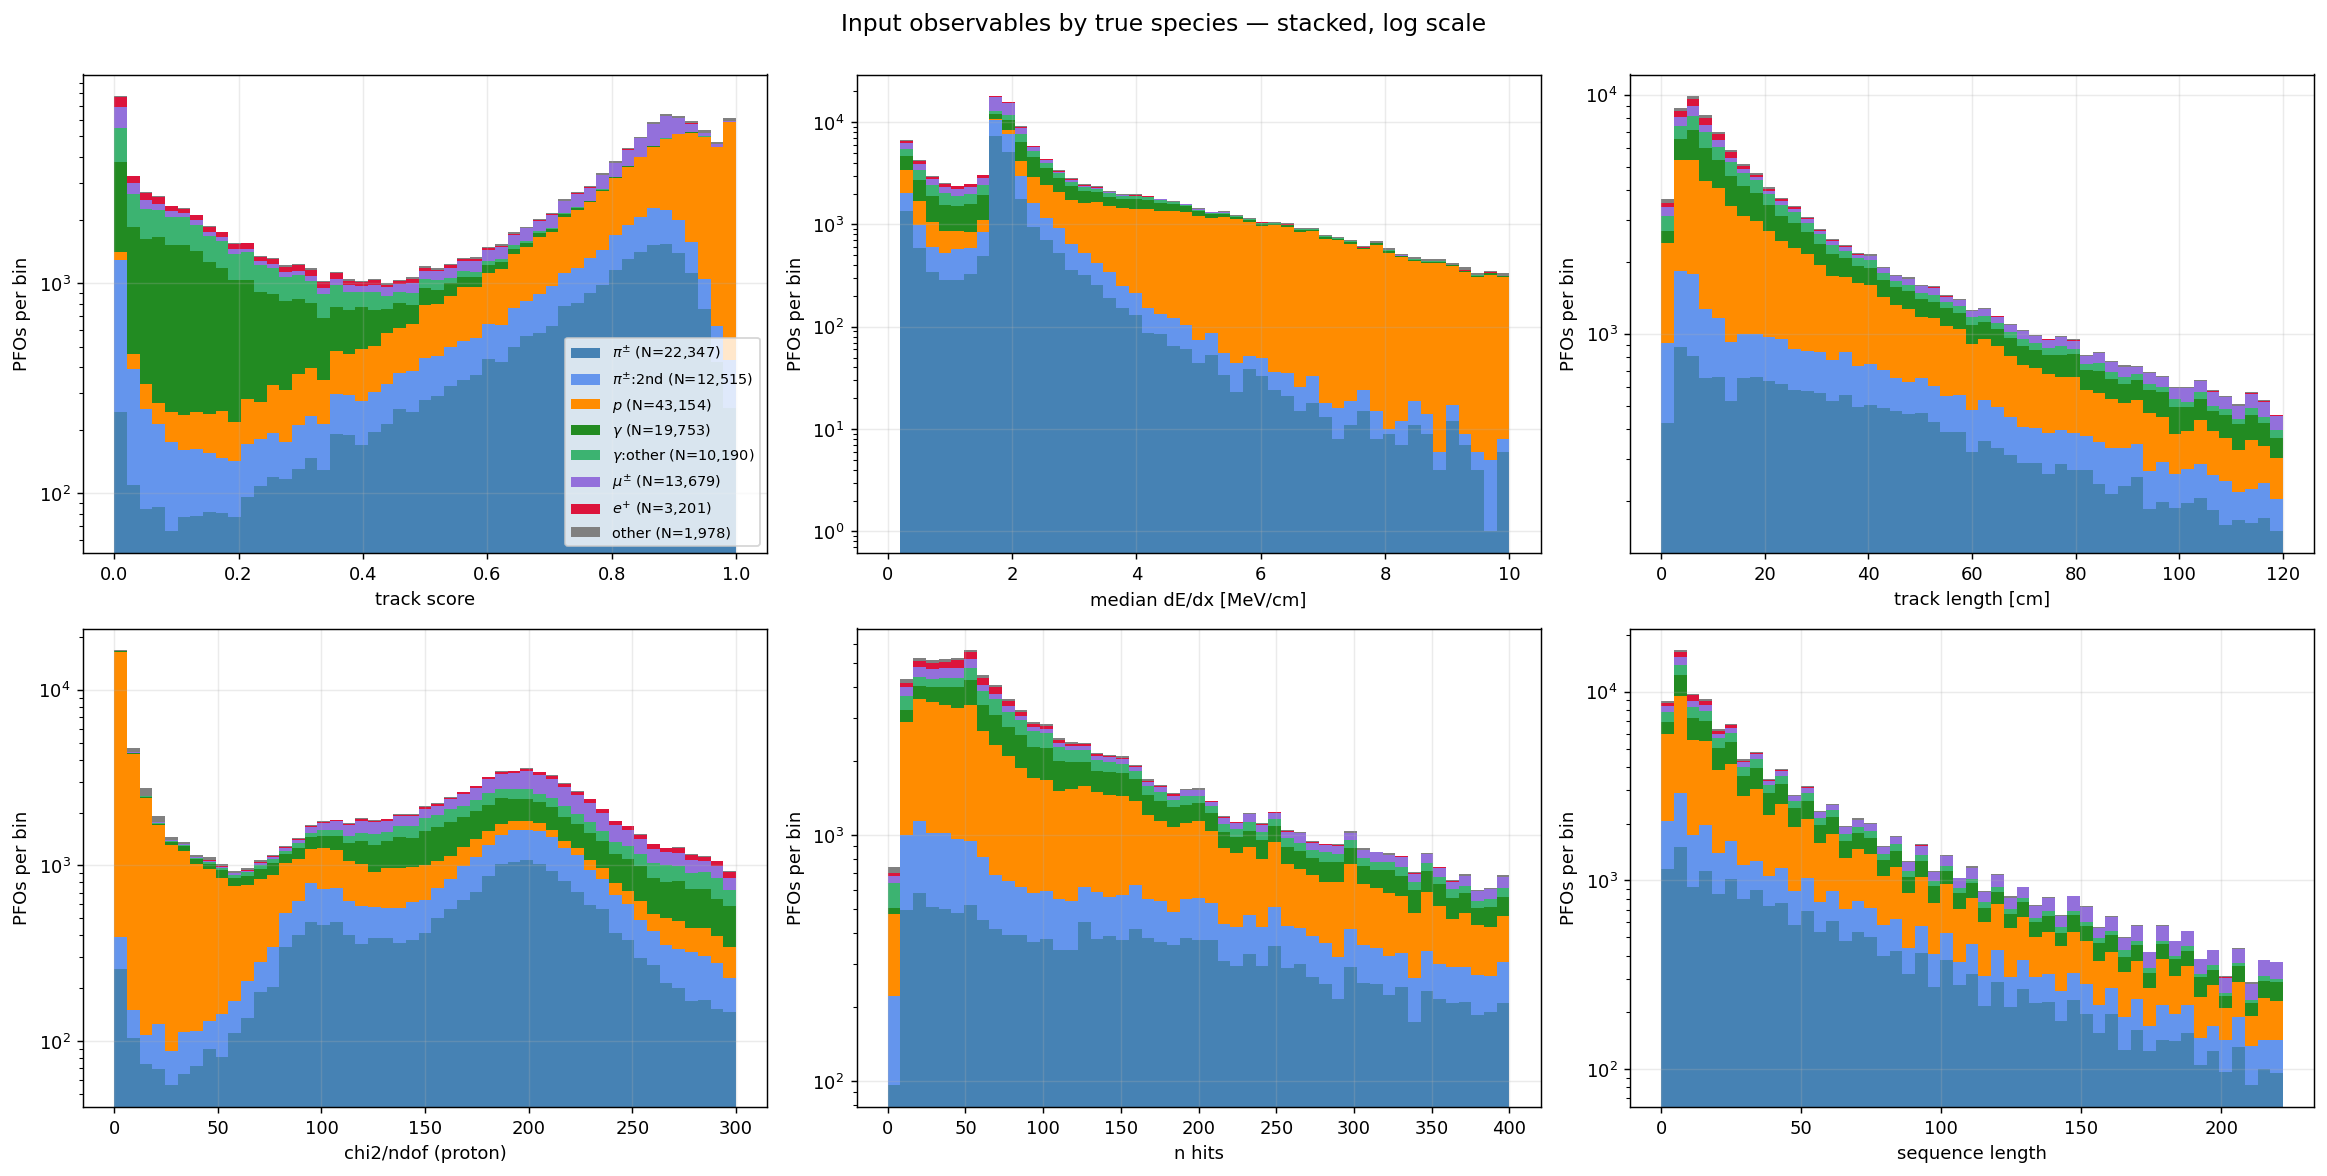

Saved /home/pemb7173/PDSP-pion-classification/plots/plot-observables/observables_1D_stacked_logy.pdf


In [2]:
# 1D observables by species, area-normalised
OBS = [('track_score','track score',(0,1)),
       ('dEdX_median','median dE/dx [MeV/cm]',(0,10)),
       ('track_length','track length [cm]',(0,120)),
       ('track_chi2/ndof_proton','chi2/ndof (proton)',(0,300)),
       ('n_hits','n hits',(0,400)),
       ('sequence_length','sequence length',(0,222))]

data   = {lab: np.array([float(t[key]) for t in tracks]) for key, lab, _ in OBS}
ranges = {lab: rng for _, lab, rng in OBS}

stacked_by_species(
    data, species, SPECIES_ALL, SPECIES_COLORS, ranges,
    suptitle=f"Input observables by true species — stacked, raw counts "
             f"(N = {Ntot:,})",
    out_path=PLOTS_DIR / "observables_1D_stacked.pdf",
)

# log-y version: reveals the low-statistics tails (Shyam, 29 July)
stacked_by_species(
    data, species, SPECIES_ALL, SPECIES_COLORS, ranges, logy=True,
    suptitle="Input observables by true species — stacked, log scale",
    out_path=PLOTS_DIR / "observables_1D_stacked_logy.pdf",
)

## 2D histogram

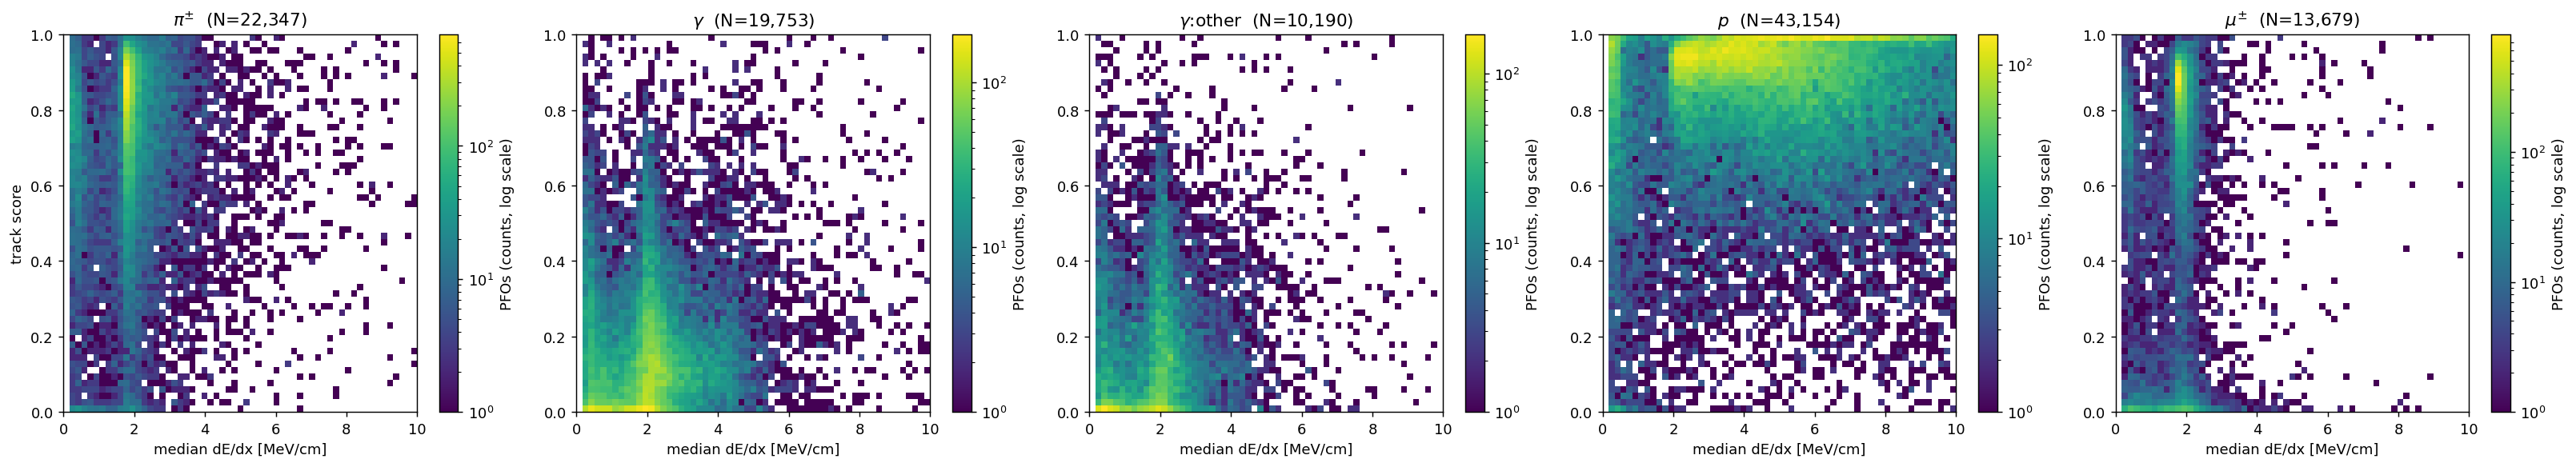

In [3]:
# 2D histogram: track score vs median dE/dx, one panel per species
from matplotlib.colors import LogNorm

SHOW = [r'$\pi^{\pm}$', r'$\gamma$', r'$\gamma$:other', '$p$', r'$\mu^{\pm}$']

x = np.array([float(t['dEdX_median']) for t in tracks])
y = np.array([float(t['track_score']) for t in tracks])
xb = np.linspace(0, 10, 60); yb = np.linspace(0, 1, 60)

fig, ax = plt.subplots(1, len(SHOW), figsize=(5*len(SHOW), 4.6), dpi=130)

for k, sp in enumerate(SHOW):
    m = species == sp
    h = ax[k].hist2d(x[m], y[m], bins=[xb, yb], norm=LogNorm(), cmap='viridis')
    ax[k].set_title(f"{sp}  (N={int(m.sum()):,})")
    ax[k].set_xlabel('median dE/dx [MeV/cm]')
    if k == 0: ax[k].set_ylabel('track score')
    fig.colorbar(h[3], ax=ax[k], label='PFOs (counts, log scale)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "observables_2D.pdf", bbox_inches="tight")
plt.show()

## Appendix A observables

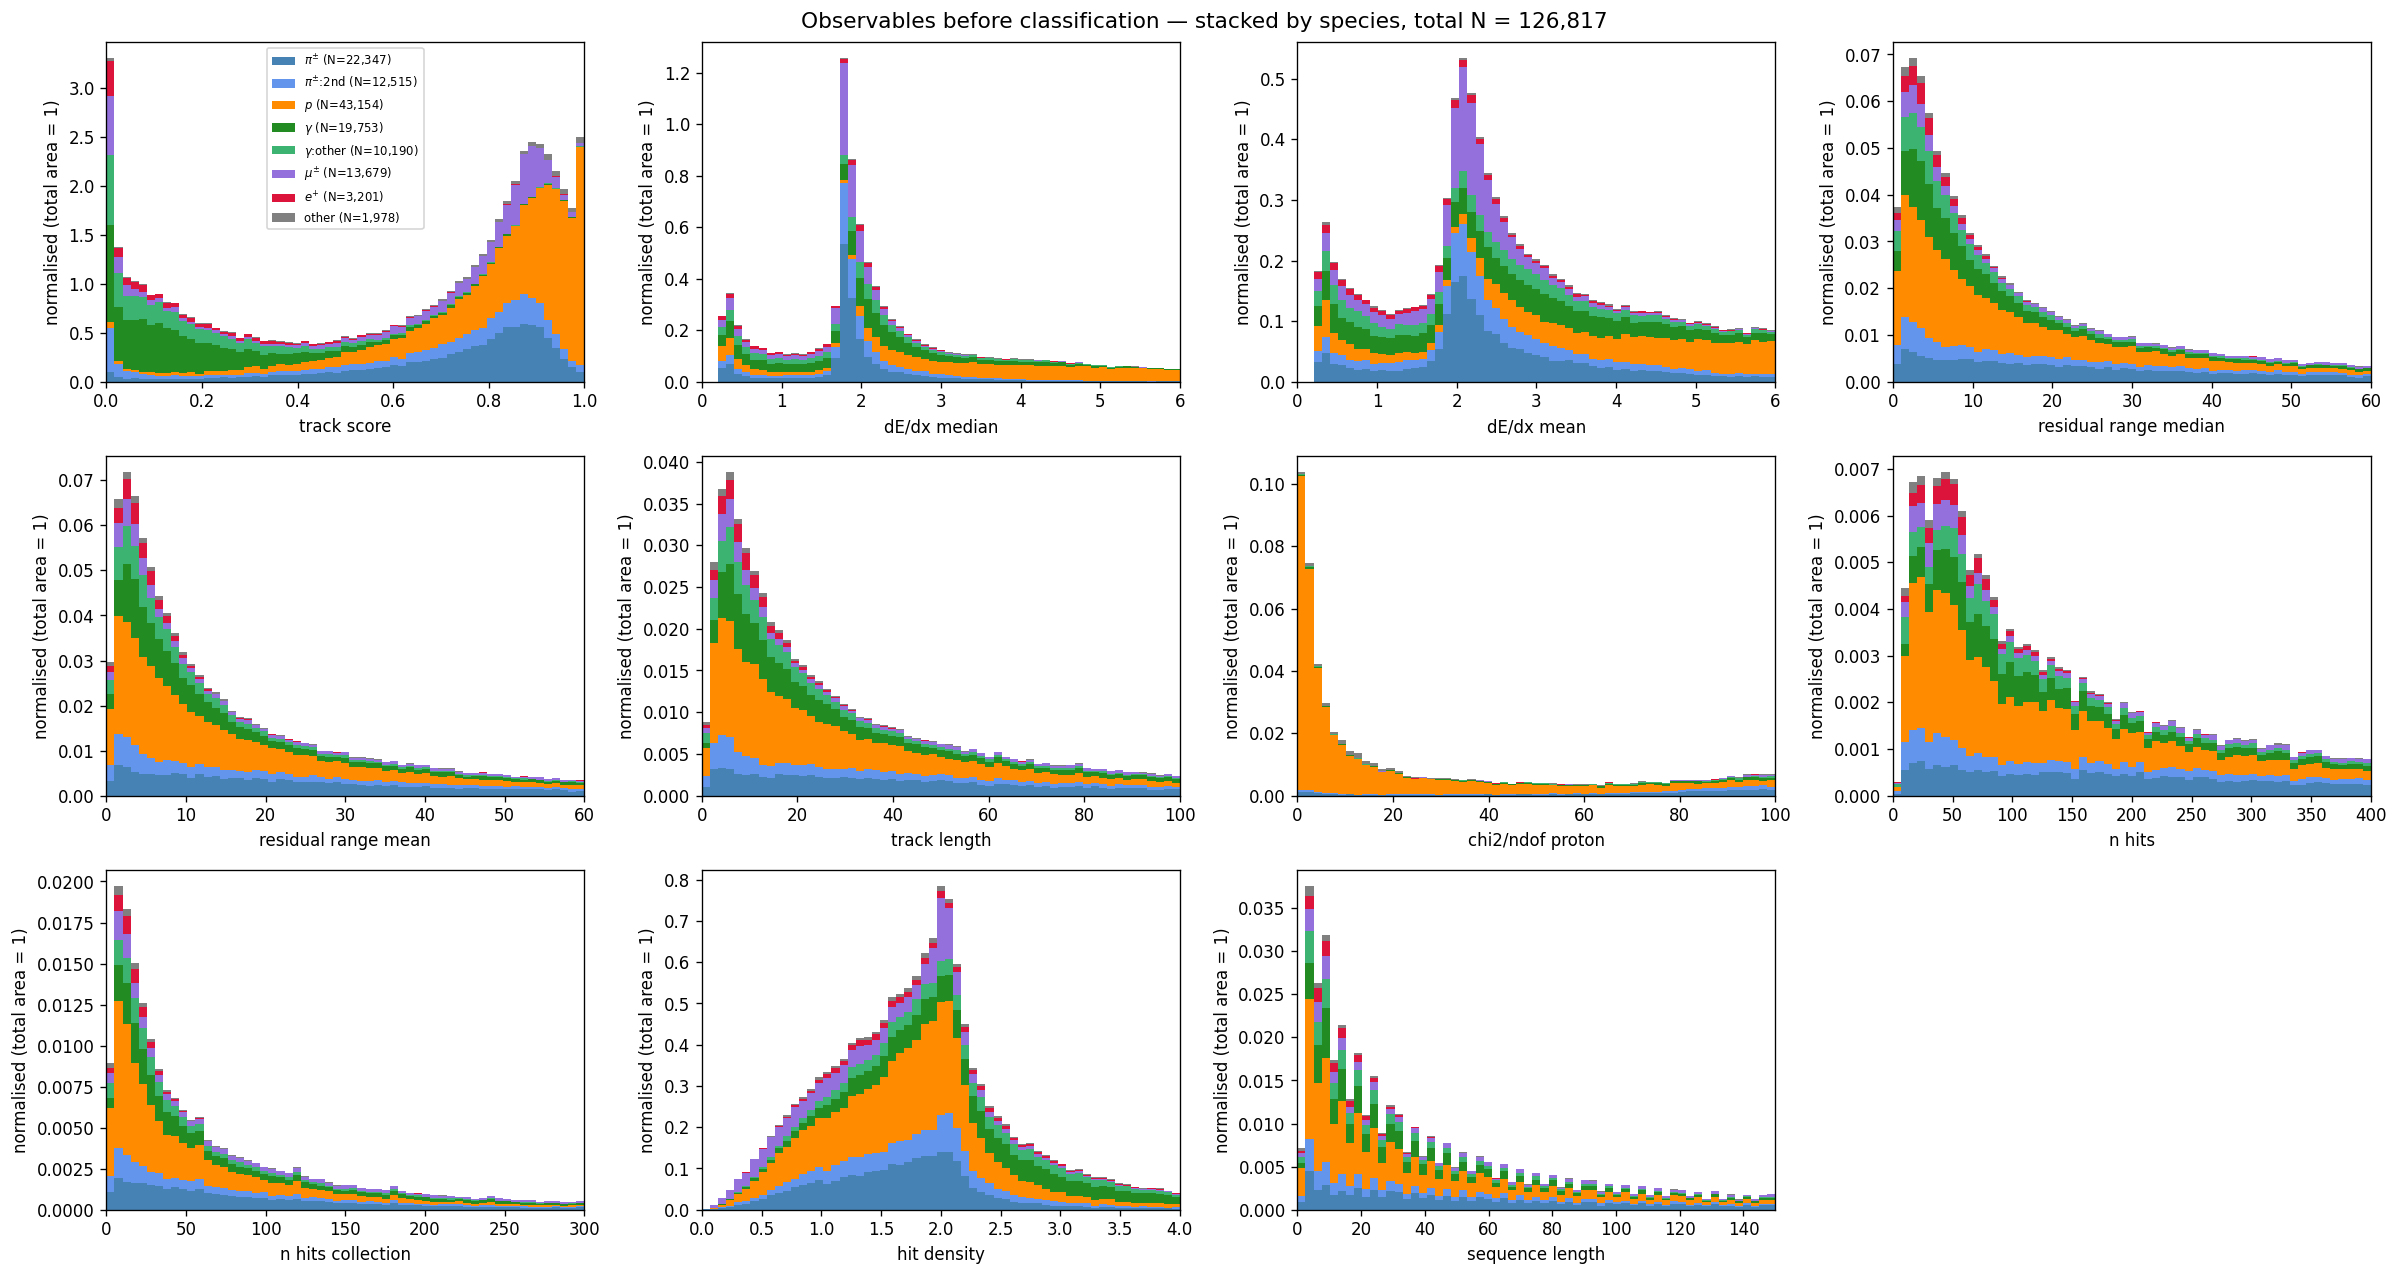

Saved /home/pemb7173/PDSP-pion-classification/plots/plot-observables/appendixA_observables.pdf


In [4]:
# observables tracked by species, stacked, per-observable tuned ranges
SHOW = SPECIES_ALL

RANGES = {'track score':(0,1), 'dE/dx median':(0,6), 'dE/dx mean':(0,6),
          'residual range median':(0,60), 'residual range mean':(0,60),
          'track length':(0,100), 'chi2/ndof proton':(0,100),
          'n hits':(0,400), 'n hits collection':(0,300),
          'hit density':(0,4), 'sequence length':(0,150)}
NBINS = 60

counts = {sp: int((species == sp).sum()) for sp in SHOW}

def obs(t):
    L = int(t['sequence_length'])
    d  = np.asarray(t['dEdX_sequence'], float)[:L]
    rr = np.asarray(t['residual_range_sequence'], float)[:L]
    tl = float(t['track_length'])
    return {
        'track score': float(t['track_score']),
        'dE/dx median': float(t['dEdX_median']),
        'dE/dx mean': float(np.mean(d)) if len(d) else np.nan,
        'residual range median': float(np.median(rr)) if len(rr) else np.nan,
        'residual range mean': float(np.mean(rr)) if len(rr) else np.nan,
        'track length': tl,
        'chi2/ndof proton': float(t['track_chi2/ndof_proton']),
        'n hits': float(t['n_hits']),
        'n hits collection': float(t['n_hits_collection']),
        'hit density': float(t['n_hits_collection']) / tl if tl > 0 else np.nan,
        'sequence length': float(t['sequence_length']),
    }

O = [obs(t) for t in tracks]
names = list(O[0].keys())
data = {n: np.array([o[n] for o in O]) for n in names}

ncol = 4; nrow = int(np.ceil(len(names) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(20, 3.6*nrow), dpi=120); ax = ax.ravel()

for j, n in enumerate(names):
    v = data[n]
    lo, hi = RANGES.get(n, tuple(np.nanpercentile(v, [0.5, 99.5])))
    b = np.linspace(lo, hi, NBINS)
    arrs = [v[species == s] for s in SHOW]
    ax[j].hist(arrs, bins=b, stacked=True, density=True,
               color=[SPECIES_COLORS[s] for s in SHOW],
               label=[f"{s} (N={counts[s]:,})" for s in SHOW], edgecolor='none')
    ax[j].set_xlim(lo, hi); ax[j].set_xlabel(n); ax[j].set_ylabel('normalised (total area = 1)')

for j in range(len(names), len(ax)):
    ax[j].axis('off')
ax[0].legend(fontsize=7)

fig.suptitle(f"Observables before classification — stacked by species, total N = {Ntot:,}", fontsize=13)
plt.tight_layout()
out_path = PLOTS_DIR / "appendixA_observables.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")